<a href="https://colab.research.google.com/github/flatwaze/Learning-Algorithms-Implementations/blob/main/HOG.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [5]:
# do not change the code in the block below
# __________start of block__________
import json
import os
import cv2
import random

import numpy as np
import torch
import torchvision
from IPython.display import clear_output
from matplotlib import pyplot as plt
from torchvision.datasets import FashionMNIST

# __________end of block__________

100%|██████████| 26.4M/26.4M [00:01<00:00, 17.4MB/s]
100%|██████████| 29.5k/29.5k [00:00<00:00, 337kB/s]
100%|██████████| 4.42M/4.42M [00:00<00:00, 6.29MB/s]
100%|██████████| 5.15k/5.15k [00:00<00:00, 9.87MB/s]


Text(0.5, 1.0, 'Image label: 1')

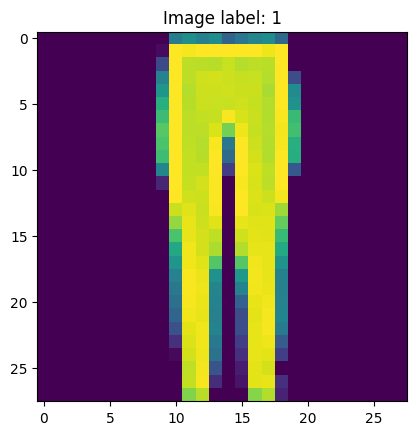

In [4]:
# do not change the code in the block below
# __________start of block__________

train_fmnist_data = FashionMNIST(
    ".", train=True, transform=torchvision.transforms.ToTensor(), download=True
)

train_data_loader = torch.utils.data.DataLoader(
    train_fmnist_data, batch_size=32, shuffle=True, num_workers=2
)

random_batch = next(iter(train_data_loader))
_image, _label = random_batch[0][0], random_batch[1][0]
plt.figure()
plt.imshow(_image.reshape(28, 28))
plt.title(f"Image label: {_label}")
# __________end of block__________

In [6]:
# do not change the code in the block below
# __________start of block__________
import numpy as np
def compute_sobel_gradients_two_loops(image):
    # Get image dimensions
    height, width = image.shape

    # Initialize output gradients
    gradient_x = np.zeros_like(image, dtype=np.float64)
    gradient_y = np.zeros_like(image, dtype=np.float64)

    # Pad the image with zeros to handle borders
    padded_image = np.pad(image, ((1, 1), (1, 1)), mode='constant', constant_values=0)
# __________end of block__________

    # Define the Sobel kernels for X and Y gradients
    sobel_x = np.array([[-1, 0, 1], [-2, 0, 2], [-1, 0, 1]])
    sobel_y = sobel_x.T

    # Apply Sobel filter for X and Y gradients using convolution
    for i in range(1, height + 1):
        for j in range(1, width + 1):
            filter = padded_image[i-1:i+2, j-1:j+2]
            gradient_x[i-1, j-1] = np.sum(filter * sobel_x)
            gradient_y[i-1, j-1] = np.sum(filter * sobel_y)
    return gradient_x, gradient_y

Text(0.5, 1.0, 'Image label: 5')

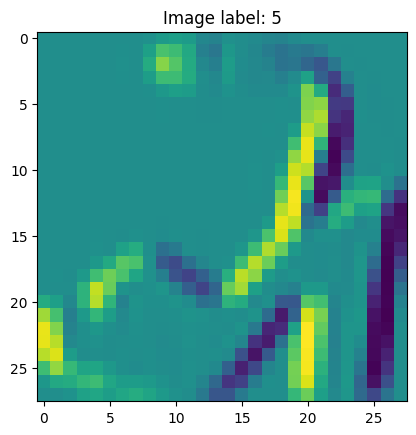

In [7]:
random_batch = next(iter(train_data_loader))
_image, _label = random_batch[0][0], random_batch[1][0]

plt.figure()
plt.imshow(compute_sobel_gradients_two_loops(_image[0].numpy())[0].reshape(28, 28))
plt.title(f"Image label: {_label}")


In [8]:
# do not change the code in the block below
# __________start of block__________
def compute_sobel_gradients_opencv(image):
    # Apply Sobel filter for horizontal and vertical gradients
    sobel_x = cv2.Sobel(image, cv2.CV_64F, 1, 0, ksize=3)
    sobel_y = cv2.Sobel(image, cv2.CV_64F, 0, 1, ksize=3)

    # Return gradients in both directions
    return sobel_x, sobel_y
# __________end of block__________


In [9]:
# do not change the code in the block below
# __________start of block__________
image = train_fmnist_data[7][0][0].numpy()
gradients_two_loops = compute_sobel_gradients_two_loops(image)
gradients_opencv = compute_sobel_gradients_opencv(image)

assert np.allclose(gradients_two_loops[0][1:-1, 1:-1], gradients_opencv[0][1:-1, 1:-1], atol=1e-2), "gradients_two_loops[0] and gradients_opencv[0] are not close"
assert np.allclose(gradients_two_loops[1][1:-1, 1:-1], gradients_opencv[1][1:-1, 1:-1], atol=1e-2), "gradients_two_loops[1] and gradients_opencv[1] are not close"
print("Everything seems fine!")
# __________end of block__________


Everything seems fine!


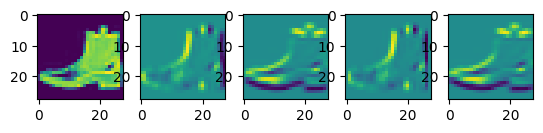

In [10]:
image = random.choice(train_fmnist_data)[0][0].numpy()
gradients_two_loops = compute_sobel_gradients_two_loops(image)
gradients_cv = compute_sobel_gradients_opencv(image)

plt.subplot(1, 5, 1)
plt.imshow(image)
plt.subplot(1, 5, 2)
plt.imshow(gradients_two_loops[0])
plt.subplot(1, 5, 3)
plt.imshow(gradients_two_loops[1])
plt.subplot(1, 5, 4)
plt.imshow(gradients_cv[0])
plt.subplot(1, 5, 5)
plt.imshow(gradients_cv[1])

In [11]:
import numpy as np # for your convenience when you copy the code to the contest
def compute_gradient_magnitude(sobel_x, sobel_y):
    return (sobel_x * sobel_x + sobel_y * sobel_y)**1/2


def compute_gradient_direction(sobel_x, sobel_y):
    '''
    Compute the direction of the gradient given the x and y gradients. Angle must be in degrees in the range (-180; 180].
    Use arctan2 function to compute the angle.

    Inputs:
        sobel_x: numpy array of the x gradient.
        sobel_y: numpy array of the y gradient.

    Returns:
        gradient_direction: numpy array of the same shape as the input [0] with the direction of the gradient.
    '''
    # YOUR CODE HERE
    return np.arctan2(sobel_x, sobel_y)/np.pi * 180


In [12]:
# do not change the code in the block below
# __________start of block__________
image = train_fmnist_data[7][0][0].numpy()
gradients_two_loops = compute_sobel_gradients_two_loops(image)

magnitudes = compute_gradient_magnitude(gradients_two_loops[0], gradients_two_loops[1])
angles = compute_gradient_direction(gradients_two_loops[0], gradients_two_loops[1])

assert np.all(magnitudes >= 0), "Magnitudes should be non-negative"
assert np.all(angles > -180) and np.all(angles <= 180), "Angles should be in the range (-180, 180]"
print("Everything seems fine!")
# __________end of block__________


Everything seems fine!


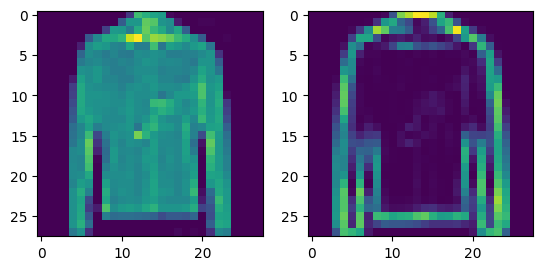

In [13]:
image = random.choice(train_fmnist_data)[0][0].numpy()
magnitudes = compute_gradient_magnitude(*compute_sobel_gradients_two_loops(image))

plt.subplot(1, 2, 1)
plt.imshow(image)
plt.subplot(1, 2, 2)
plt.imshow(magnitudes)

In [1]:
cell_size = 7
def compute_hog(image, pixels_per_cell=(cell_size, cell_size), bins=9):
    # 1. Convert the image to grayscale if it's not already (assuming the image is in RGB or BGR)
    if len(image.shape) == 3:
        image = np.mean(image, axis=2)  # Simple averaging to convert to grayscale

    # 2. Compute gradients with Sobel filter
    gradient_x, gradient_y = compute_sobel_gradients_two_loops(image)

    # 3. Compute gradient magnitude and direction
    magnitude = compute_gradient_magnitude(gradient_x, gradient_y)
    direction = compute_gradient_direction(gradient_x, gradient_y)

    # 4. Create histograms of gradient directions for each cell
    cell_height, cell_width = pixels_per_cell
    n_cells_x = image.shape[1] // cell_width
    n_cells_y = image.shape[0] // cell_height

    histograms = np.zeros((n_cells_y, n_cells_x, bins))

    for i in range(n_cells_y):
        for j in range(n_cells_x):
            window_dir = direction[cell_height * i : cell_height * (i+1), cell_width * j : cell_width * (j+1)]
            window_mag = magnitude[cell_height * i : cell_height * (i+1), cell_width * j : cell_width * (j+1)]
            for k in range(bins):
                ind = np.where((-180 + 40 * k < window_dir) & (window_dir <= -180 + 40 * (k+1)))
                histograms[i, j, k] = np.sum(window_mag[ind])
            if np.sum(histograms[i, j]) > 0:
                histograms[i, j] = histograms[i, j]/np.sum(histograms[i, j])


    return histograms

Для запуска тестов ниже файлы `hog_data.npy` и `image_data.npy` из репозитория должны быть доступны в той же директории, что и ноутбук. Вы можете скачать их в репозитории.

Визуализация полученных гистограмм. Сетка выглядит чуть сдвинутой из-за существенного размера пискеля, это нормально.

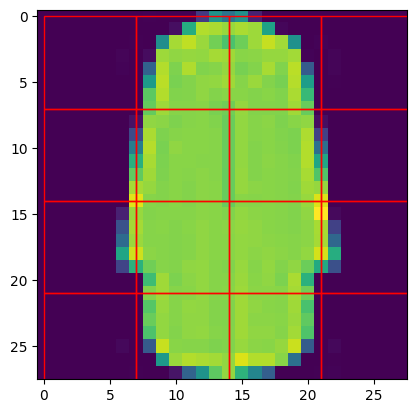

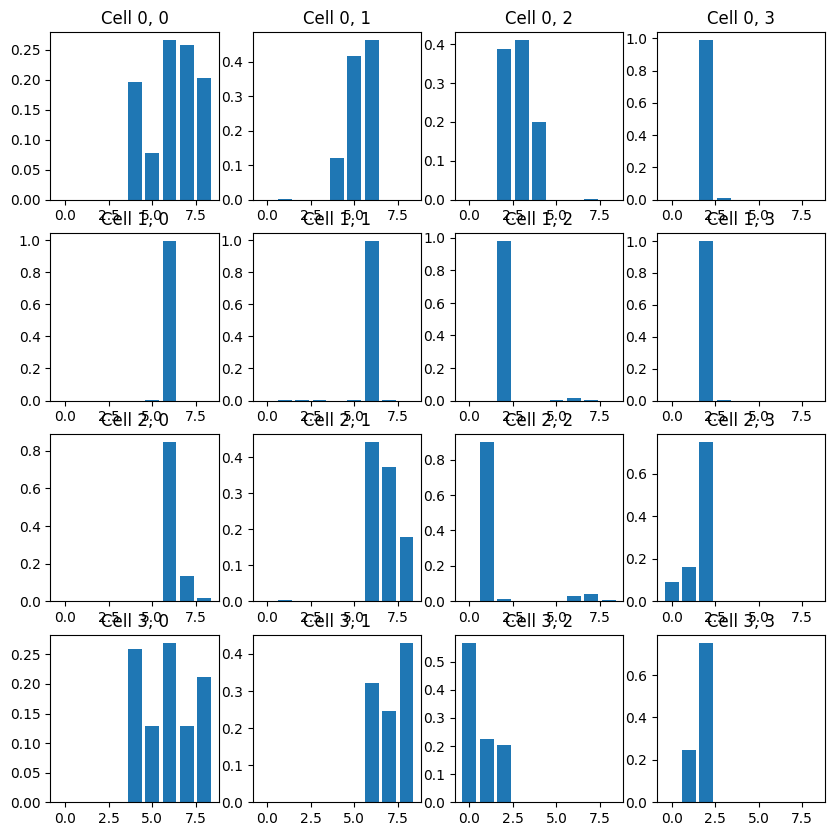

In [14]:
#plot all the histograms for (3, 3) cells:
image = random.choice(train_fmnist_data)[0][0].numpy()
hog = compute_hog(image)

# draw cells on the image
plt.imshow(image)
for i in range(4):
    for j in range(4):
        plt.gca().add_patch(plt.Rectangle((j * cell_size, i * cell_size), cell_size, cell_size, fill=False, edgecolor='red', linewidth=1))
plt.show()


plt.figure(figsize=(10, 10))
for i in range(4):
    for j in range(4):
        plt.subplot(4, 4, i * 4 + j + 1)
        plt.bar(range(len(hog[i, j])), hog[i, j])
        plt.title(f"Cell {i}, {j}")
plt.show()
